# Hierarchical clustering and Gaussian mixtures: solutions

Both of these methods find **groups in data without being told the answers**. This is called **clustering**, and it is a kind of **unsupervised learning**.

- **Hierarchical clustering** joins the closest points together, one step at a time, and builds a **tree** of groups.
- **Gaussian mixtures** look for **hills** in a pile of measurements, and say how likely each point is to belong to each hill.

**How to use this notebook**

- Run each cell in order with **Shift + Enter**.
- Cells marked **Exercise** need you to do something. Most just need you to replace `___` with the right value, or answer a question in a text cell.
- Some cells check your answer for you and print *Correct* or *Not quite*.
- If something breaks, use **Kernel > Restart & Run All** and work down from the top again.

*This copy has every exercise completed, with answers in the text cells.*

## Key words

| Word | Meaning |
|---|---|
| **Cluster** | A group of points that are close to each other |
| **Distance** | How far apart two points are, measured in a straight line |
| **Dendrogram** | A tree diagram that shows the order in which groups were joined |
| **Cutting the tree** | Drawing a line across the dendrogram to choose how many groups we want |
| **Hill** | A pile of measurements bunched around a middle value. Also called a **bell curve** or **Gaussian** |
| **Gaussian mixture** | Two or more hills added together |

## Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings("ignore")   # hide technical warnings so the output is easier to read

# Part 1: Hierarchical clustering

We start with just **6 points**, called A to F, so you can follow every step.

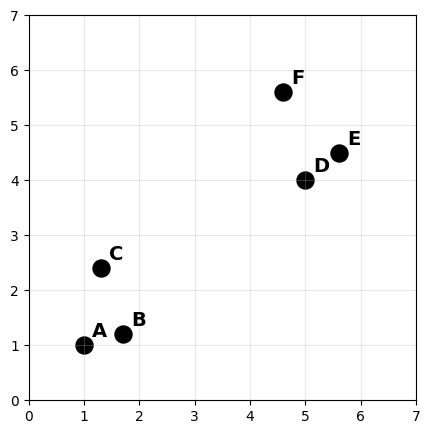

In [2]:
names = ["A", "B", "C", "D", "E", "F"]
points = np.array([[1.0, 1.0],
                   [1.7, 1.2],
                   [1.3, 2.4],
                   [5.0, 4.0],
                   [5.6, 4.5],
                   [4.6, 5.6]])

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], s=150, color="black")
for name, (x, y) in zip(names, points):
    plt.text(x + 0.15, y + 0.15, name, fontsize=14, fontweight="bold")
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.grid(alpha=0.3)
plt.show()

### Exercise 1: think first

Look at the chart. Without writing any code:

a) How many groups can you see?

b) Which **two points** look closest together? These will be joined first.

**Answer:** a) Two groups: A, B and C in the bottom left, and D, E and F in the top right. b) A and B look closest. D and E are also very close, so it is hard to be sure by eye. The next exercise measures it properly.

### Exercise 2: measure a distance by hand

The straight-line distance between two points uses Pythagoras:

> distance = √( (difference in x)² + (difference in y)² )

A is at (1.0, 1.0) and B is at (1.7, 1.2). Fill in the blank to work out the distance between them. `np.sqrt` takes a square root and `**2` squares a number.

In [3]:
distance_AB = np.sqrt((1.7 - 1.0)**2 + (1.2 - 1.0)**2)
print("Distance from A to B:", round(distance_AB, 2))

Distance from A to B: 0.73


In [4]:
# Check cell: just run this
if abs(distance_AB - 0.728) < 0.01:
    print("Correct!")
else:
    print("Not quite. A is at (1.0, 1.0) and B is at (1.7, 1.2).")

Correct!


Doing that by hand for every pair would take a while, so here is a table of **every** distance. Read it like a mileage chart: the row is one point, the column is the other.

In [5]:
distances = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        distances[i, j] = np.sqrt(((points[i] - points[j]) ** 2).sum())

pd.DataFrame(distances, index=names, columns=names).round(2)

,A,B,C,D,E,F
A,0.00,0.73,1.43,5.00,5.78,5.84
B,0.73,0.00,1.26,4.33,5.11,5.27
C,1.43,1.26,0.00,4.03,4.79,4.60
D,5.00,4.33,4.03,0.00,0.78,1.65
E,5.78,5.11,4.79,0.78,0.00,1.49
F,5.84,5.27,4.60,1.65,1.49,0.00


### Exercise 3: read the table

a) Apart from the 0s, what is the **smallest** distance in the table, and which two points does it belong to?

b) What is the **second smallest**?

c) Why are there 0s running down the middle of the table?

**Answer:** a) **0.73**, between A and B, so they are joined first. b) **0.78**, between D and E, so they are joined second. c) Each 0 is the distance from a point to itself, for example A to A.

### Exercise 4: let the computer do the joining

SciPy's `linkage` function does all the joins for us. Fill in the blank with `"single"`. Single linkage means the distance between two groups is the distance between their **closest** pair of points.

The rest of the cell just prints each join in plain English.

In [6]:
joins = linkage(points, method="single")

groups = {i: names[i] for i in range(6)}      # each point starts as its own group
for step, (a, b, dist, size) in enumerate(joins, start=1):
    new_group = "".join(sorted(groups[int(a)] + groups[int(b)]))
    print(f"Step {step}: join {groups[int(a)]:>3} + {groups[int(b)]:<3}  at distance {dist:.2f}")
    groups[6 + step - 1] = new_group

Step 1: join   A + B    at distance 0.73
Step 2: join   D + E    at distance 0.78
Step 3: join   C + AB   at distance 1.26
Step 4: join   F + DE   at distance 1.49
Step 5: join ABC + DEF  at distance 4.03


Six points took **five** joins to end up as one big group. How many joins would **10** points need? Can you spot the rule?

**Answer:** **9** joins. Every join turns two groups into one, so the number of groups goes down by one each time. To go from 10 groups to 1 group takes 10 - 1 = 9 joins. The rule is *number of points - 1*.

## The tree (dendrogram)

A **dendrogram** shows every join as a tree. Each point is a leaf at the bottom, each flat bar is a join, and the **height** of the bar is the distance at which the join happened.

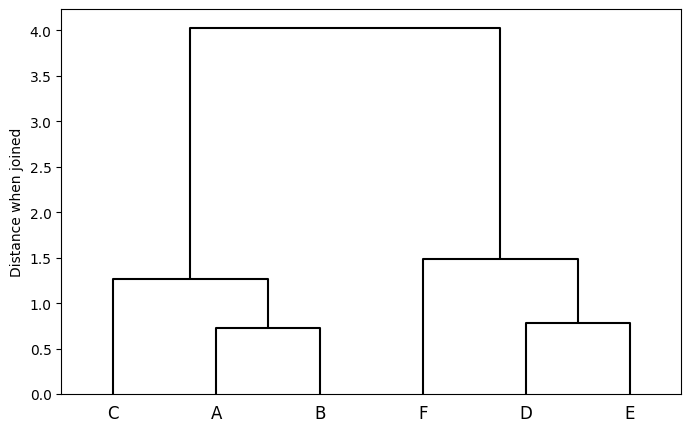

In [7]:
plt.figure(figsize=(8, 5))
dendrogram(joins, labels=names, color_threshold=0, above_threshold_color="black")
plt.ylabel("Distance when joined")
plt.show()

### Exercise 5: read the tree

a) At what height do the two big groups (ABC and DEF) finally join?

b) Look at the gap between the last two joins. Why does a **big gap** suggest the data really has two groups?

**Answer:** a) At about **4.03**, the tall bar at the top. b) Inside each group, points join at small distances (all under 1.5). Then nothing happens until 4.03. That long gap means the two groups are much further from each other than their own points are from one another, which is exactly what a real group looks like.

### Exercise 6: cut the tree

To get groups, we **cut** the tree with a horizontal line at a chosen height. Every vertical line it crosses becomes one group.

Fill in the blank with a cut height of **2.5**, which is in the big gap.

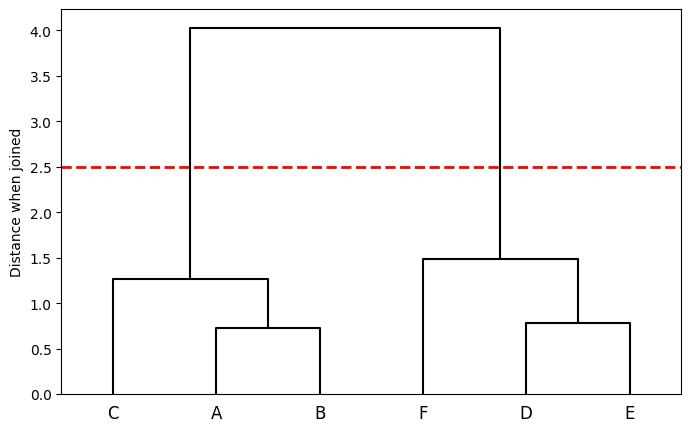

Number of groups: 2
Group 1: A, B, C
Group 2: D, E, F


In [8]:
cut_height = 2.5

plt.figure(figsize=(8, 5))
dendrogram(joins, labels=names, color_threshold=0, above_threshold_color="black")
plt.axhline(cut_height, color="red", linestyle="--", linewidth=2)
plt.ylabel("Distance when joined")
plt.show()

labels = fcluster(joins, t=cut_height, criterion="distance")
print("Number of groups:", len(set(labels)))
for group in sorted(set(labels)):
    members = [n for n, l in zip(names, labels) if l == group]
    print(f"Group {group}: {', '.join(members)}")

In [9]:
# Check cell: just run this
if len(set(labels)) == 2:
    print("Correct! Two groups.")
else:
    print("Not quite. Set cut_height to 2.5 and run the cell above again.")

Correct! Two groups.


### Exercise 7: cut lower

Copy the cell from Exercise 6 into the empty cell below, and change the cut height to **1.0**.

How many groups do you get now, and which points are in each one?

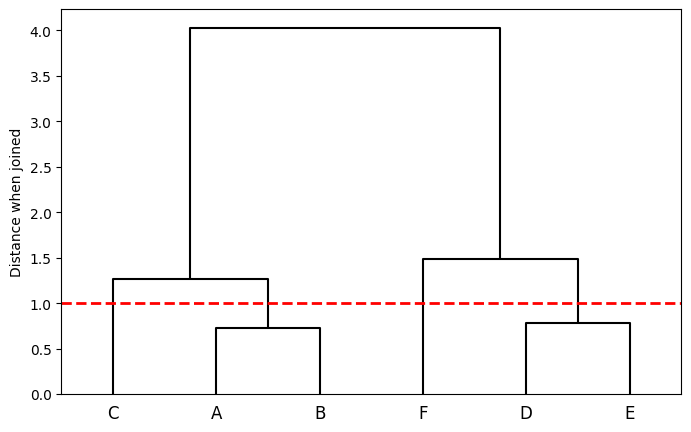

Number of groups: 4
Group 1: A, B
Group 2: C
Group 3: D, E
Group 4: F


In [10]:
cut_height = 1.0

plt.figure(figsize=(8, 5))
dendrogram(joins, labels=names, color_threshold=0, above_threshold_color="black")
plt.axhline(cut_height, color="red", linestyle="--", linewidth=2)
plt.ylabel("Distance when joined")
plt.show()

labels = fcluster(joins, t=cut_height, criterion="distance")
print("Number of groups:", len(set(labels)))
for group in sorted(set(labels)):
    members = [n for n, l in zip(names, labels) if l == group]
    print(f"Group {group}: {', '.join(members)}")

**Answer:** **Four** groups: A and B, C on its own, D and E, and F on its own. The line at 1.0 is above the first two joins (0.73 and 0.78) but below the joins where C and F come in (1.26 and 1.49), so C and F are still by themselves. Cutting lower gives more, smaller groups. Cutting higher gives fewer, bigger groups.

# Part 2: Gaussian mixtures

Now for a different kind of data. We have a box of **200 apples** and we weigh every one. This is **simulated data**: we made up 120 apples of one kind and 80 of another, and mixed them in the same box.

The model will **not** be told which kind each apple is. It only sees the weights.

In [11]:
rng = np.random.default_rng(4)      # fixed seed, so everyone gets the same apples

kind_1 = rng.normal(150, 12, 120)   # 120 apples, around 150 g
kind_2 = rng.normal(190, 16, 80)    # 80 apples, around 190 g
all_apples = np.concatenate([kind_1, kind_2])

print("Apples in the box:", len(all_apples))
print("First ten weights:", all_apples[:10].round(1))

Apples in the box: 200
First ten weights: [142.2 147.9 170.  157.9 130.3 149.9 142.5 151.8 130.7 152.9]


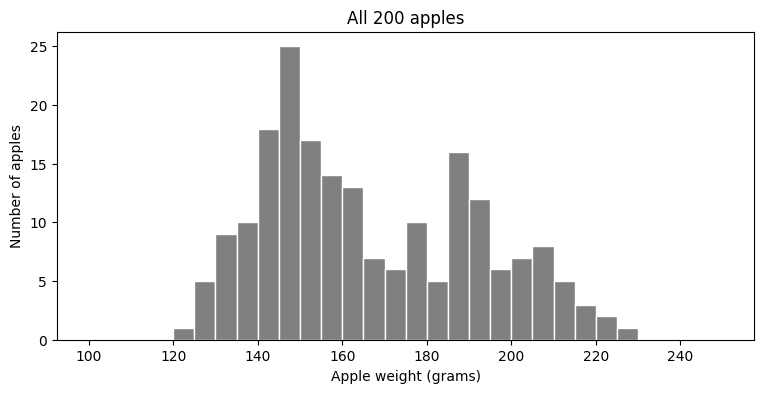

In [12]:
bins = np.arange(100, 255, 5)       # weight ranges: 100-105 g, 105-110 g, ...

plt.figure(figsize=(9, 4))
plt.hist(all_apples, bins=bins, color="grey", edgecolor="white")
plt.xlabel("Apple weight (grams)")
plt.ylabel("Number of apples")
plt.title("All 200 apples")
plt.show()

### Exercise 8: think first

Look at the chart. Each bar shows how many apples weigh about that much.

a) How many **hills** (bumps) can you see?

b) Roughly what weight is the **middle** of each hill?

c) Where would you be **least sure** which kind an apple is?

**Answer:** a) **Two** hills. b) One around **150 g** and one around **190 g**. c) In the dip between them, roughly **165 to 175 g**, where the two hills overlap and an apple could easily be either kind.

### Exercise 9: fit a Gaussian mixture

`GaussianMixture` looks for hills in the data. We have to tell it **how many** hills to look for. Fill in the blank.

(scikit-learn wants the weights as a single column, which is what `reshape(-1, 1)` does.)

In [13]:
X = all_apples.reshape(-1, 1)

model = GaussianMixture(n_components=2, random_state=0)
model.fit(X)

# sort the hills from lightest to heaviest, so hill 1 is always the lighter one
order = np.argsort(model.means_.ravel())
middles = model.means_.ravel()[order]
widths = np.sqrt(model.covariances_.ravel()[order])
sizes = model.weights_[order]

for i in range(len(middles)):
    print(f"Hill {i + 1}: middle {middles[i]:.0f} g, width {widths[i]:.0f} g, holds {sizes[i]:.0%} of the apples")

Hill 1: middle 149 g, width 11 g, holds 59% of the apples
Hill 2: middle 193 g, width 15 g, holds 41% of the apples


In [14]:
# Check cell: just run this
if len(middles) == 2 and abs(middles[0] - 150) < 5 and abs(middles[1] - 190) < 8:
    print("Correct! The model found two hills.")
else:
    print("Not quite. How many hills did you see in Exercise 8?")

Correct! The model found two hills.


Each hill is described by three numbers:

- **middle**: the typical weight
- **width**: how spread out the weights are (a wider hill means more variety)
- **size**: what share of all the apples belong to that hill

Here are the two hills drawn over the apples.

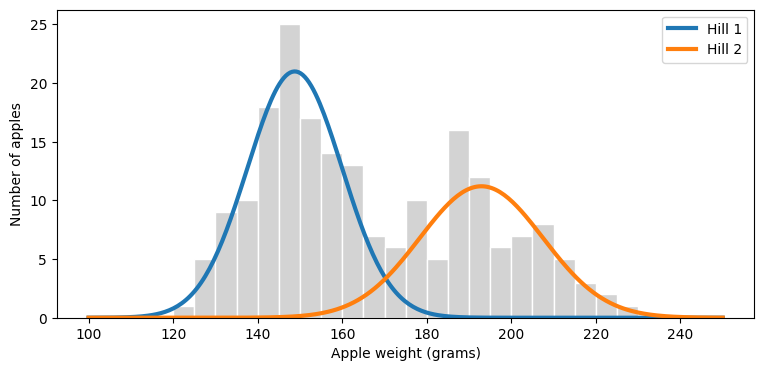

In [15]:
def bell(x, middle, width):
    return np.exp(-0.5 * ((x - middle) / width) ** 2) / (width * np.sqrt(2 * np.pi))

weights = np.linspace(100, 250, 300)

plt.figure(figsize=(9, 4))
plt.hist(all_apples, bins=bins, color="lightgrey", edgecolor="white")
plt.plot(weights, bell(weights, middles[0], widths[0]) * sizes[0] * 200 * 5, color="tab:blue", linewidth=3, label="Hill 1")
plt.plot(weights, bell(weights, middles[1], widths[1]) * sizes[1] * 200 * 5, color="tab:orange", linewidth=3, label="Hill 2")
plt.xlabel("Apple weight (grams)")
plt.ylabel("Number of apples")
plt.legend()
plt.show()

Compare the numbers the model found with the code that made the apples (`rng.normal(150, 12, 120)` and `rng.normal(190, 16, 80)`). How close did it get? Remember, it was never told which apple was which.

**Answer:** Very close. The model found middles of **149 g** and **193 g** (the real values were 150 g and 190 g), widths of **11 g** and **15 g** (real: 12 g and 16 g), and sizes of **59%** and **41%** (real: 120 and 80 out of 200, which is 60% and 40%). It worked all of this out from the weights alone.

### Exercise 10: which hill does an apple belong to?

The big strength of a Gaussian mixture is that it gives **percentages**, not just a yes or no. For each apple it compares how tall each hill is at that weight.

Three test apples are already in the list. Add a fourth apple weighing **165 g** by filling in the blank.

In [16]:
test_apples = np.array([[140.0], [170.0], [200.0], [165.0]])

percentages = model.predict_proba(test_apples)[:, order]
for apple, (p1, p2) in zip(test_apples.ravel(), percentages):
    print(f"{apple:.0f} g apple:  hill 1 {p1:6.1%}   hill 2 {p2:6.1%}")

140 g apple:  hill 1  99.9%   hill 2   0.1%
170 g apple:  hill 1  51.8%   hill 2  48.2%
200 g apple:  hill 1   0.0%   hill 2 100.0%
165 g apple:  hill 1  80.4%   hill 2  19.6%


Which of the four apples is the model **least sure** about? Why does that make sense when you look at the chart of the two hills?

**Answer:** The **170 g** apple: 51.8% hill 1 and 48.2% hill 2, which is almost a coin toss. 170 g is in the dip between the two hills, where both hills are about the same height, so the apple could easily be either kind. The 165 g apple is a bit closer to hill 1, so it gets 80.4% hill 1. The 140 g and 200 g apples sit right under one hill, so the model is almost 100% sure about them.

### Exercise 11: how many did it get right?

Because we made up the apples, we know which kind each one really is. (With real data we usually would not.) The first 120 apples are kind 1 and the last 80 are kind 2.

Fill in the blank to count how many apples the model put in the right group.

In [17]:
true_kind = np.array([1] * 120 + [2] * 80)

hill = model.predict(X)                       # most likely hill for each apple
hill = np.where(hill == order[0], 1, 2)       # name the lighter hill 1 and the heavier hill 2

correct = (hill == true_kind).sum()
print("Apples put in the right group:", correct, "out of", len(true_kind))

Apples put in the right group: 191 out of 200


In [18]:
mistakes = all_apples[hill != true_kind]
print("Weights of the apples it got wrong:", np.sort(mistakes).round(0))

Weights of the apples it got wrong: [142. 143. 148. 169. 172. 175. 175. 177. 179.]


Look at the weights of the apples it got wrong. Why do you think the model made these mistakes?

**Answer:** It got **191 out of 200** right. The 9 mistakes are apples that are unusual for their kind. Five are heavy kind 1 apples (172 to 179 g) that weigh more like kind 2, and four are light kind 2 apples (142 to 169 g) that weigh more like kind 1. The model only knows the weight, so an apple that weighs the same as the other kind looks just like the other kind. No method could get these right from weight alone.

### Exercise 12 (bonus): the wrong number of hills

What happens if we tell the model to look for **3** hills instead of 2? Fill in the blank and run the cell.

In [19]:
model_3 = GaussianMixture(n_components=3, random_state=0).fit(X)

order_3 = np.argsort(model_3.means_.ravel())
for i, k in enumerate(order_3):
    print(f"Hill {i + 1}: middle {model_3.means_.ravel()[k]:.0f} g, holds {model_3.weights_[k]:.0%} of the apples")

Hill 1: middle 145 g, holds 44% of the apples
Hill 2: middle 164 g, holds 20% of the apples
Hill 3: middle 196 g, holds 36% of the apples


The model always finds exactly the number of hills you ask for, even if that is the wrong number. One way to choose is a score called **BIC**. You do not need to know how it is worked out: just remember that **lower is better**.

In [20]:
for k in [1, 2, 3, 4]:
    m = GaussianMixture(n_components=k, random_state=0).fit(X)
    print(f"{k} hill(s): BIC = {m.bic(X):.1f}")

1 hill(s): BIC = 1868.3
2 hill(s): BIC = 1832.0
3 hill(s): BIC = 1848.4
4 hill(s): BIC = 1861.6


Which number of hills has the lowest BIC? Does that match what you saw in Exercise 8?

**Answer:** **2 hills** has the lowest BIC (1832.0). That matches the two bumps we saw in Exercise 8, and the two kinds of apple we actually put in the box. With 3 hills the model squeezes an extra small hill into the overlap around 164 g, which does not match a real kind of apple.

## Summary

| | Hierarchical clustering | Gaussian mixture |
|---|---|---|
| Main idea | Keep joining the closest groups | Find hills in the data |
| What you get | A tree (dendrogram) | The middle, width and size of each hill |
| Choosing the number of groups | Cut the tree, ideally across the biggest gap | Set `n_components`, and check with BIC |
| Each point's group | One group only | A **percentage** for each group |
| Unsure points | Forced into one group | Get a split, such as 60 / 40 |

### Final question

A shop sorts its customers by how much they spend each month. A customer who sits right between two groups gets a different discount depending on which group they are put in. Which method would you choose, and why?

**Answer:** A **Gaussian mixture**, because it gives a percentage for each group. A customer who is, say, 55 / 45 between two groups can be flagged as a borderline case, so the shop can check them rather than treating them as certain. Hierarchical clustering would put them firmly in one group with no warning that it was a close call.